In [2]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
from sklearn.linear_model import LinearRegression

ROUND_NUM = 5
BASE = 'round5'
DAYS = ['2', '3', '4']

price_rows = []
offset = 0
for day in DAYS:
    with open(f'./{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    offset += 1_000_000

prices = pd.DataFrame(price_rows)
for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')

In [4]:
pebbles = [p for p in prices['product'].unique() if str(p).startswith("SNACKPACK")]
pebbles

['SNACKPACK_RASPBERRY',
 'SNACKPACK_VANILLA',
 'SNACKPACK_CHOCOLATE',
 'SNACKPACK_PISTACHIO',
 'SNACKPACK_STRAWBERRY']

In [5]:
pebble_prices = prices[prices["product"].isin(pebbles)].copy()

In [6]:
pebble_prices.head(5)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
1,2,0,SNACKPACK_RASPBERRY,9992,36,9990,45,,,10008,36,10010,45,,,10000.0,0.0
10,2,0,SNACKPACK_VANILLA,9992,36,9990,45,,,10008,36,10010,45,,,10000.0,0.0
11,2,0,SNACKPACK_CHOCOLATE,9992,36,9990,45,,,10008,36,10010,45,,,10000.0,0.0
27,2,0,SNACKPACK_PISTACHIO,9992,36,9990,45,,,10008,36,10010,45,,,10000.0,0.0
40,2,0,SNACKPACK_STRAWBERRY,9992,36,9990,45,,,10008,36,10010,45,,,10000.0,0.0


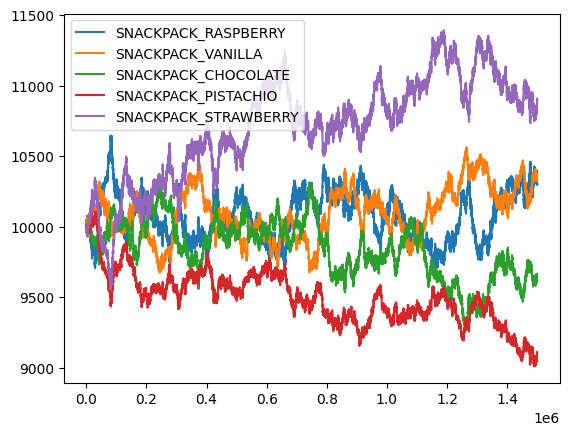

In [7]:
for p in pebbles:
    plt.plot(pebble_prices[pebble_prices['product'] == p]['mid_price'], label=p)
plt.legend()
plt.show()

In [8]:
mids = prices.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price",
).sort_index()

mids["XL_XS_avg"] = (mids["PEBBLES_XL"] + mids["PEBBLES_XS"]) / 2
mids["S_L_avg"]   = (mids["PEBBLES_S"]  + mids["PEBBLES_L"])  / 2

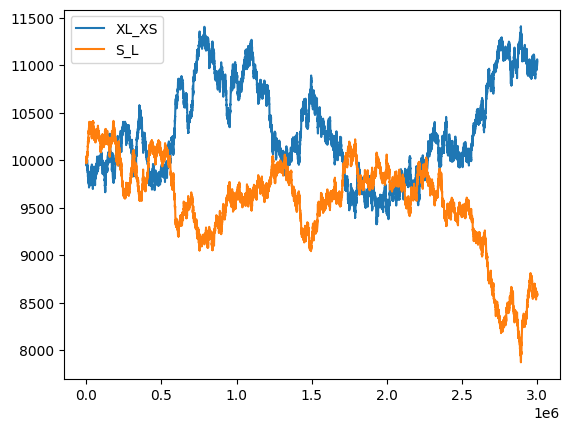

In [9]:
plt.plot(mids["XL_XS_avg"], label="XL_XS")
plt.plot(mids["S_L_avg"], label="S_L")
plt.legend()

<Axes: title={'center': 'Average mid across all PEBBLES'}, xlabel='timestamp'>

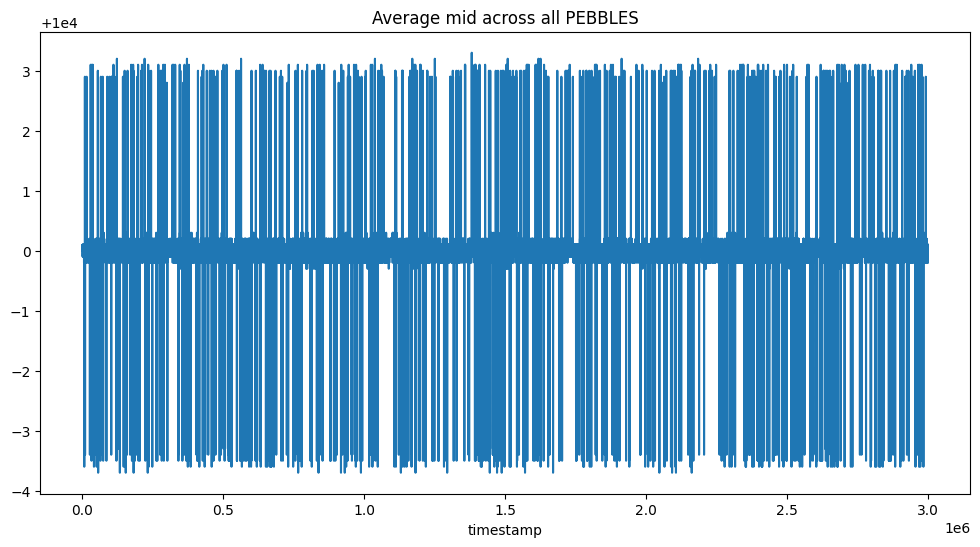

In [10]:
pebble_cols = [c for c in mids.columns if c.startswith("PEBBLES_")]
mids["PEBBLES_avg"] = mids[pebble_cols].mean(axis=1)

mids["PEBBLES_avg"].plot(figsize=(12, 6), title="Average mid across all PEBBLES")